# Conv1D Hybrid Autoencoder v3 — Entrenamiento con Hiperparametros de Optuna v2
## Dataset: SWaT A12 (Marzo 2026)

Usa los hiperparametros encontrados por Optuna v2 (objetivo ROC-AUC).
Split cronologico original — probado como el optimo para deteccion de ataques.
Guarda en `conv1d_hybrid_a12_v3` para usar en el TSTR y la validacion externa.


## 0. Imports

In [1]:
import json, joblib, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)


Device: cuda


## 1. Rutas

In [3]:
current_dir  = Path.cwd()
PROJECT_ROOT = current_dir if (current_dir / 'data').exists() else current_dir.parent

RAW_CSV    = PROJECT_ROOT / 'data' / 'clean' / 'SWaT.A12_OTDataset_Mar_26' / '11-Mar-2026_0900_1700_labeled.csv'
OPTUNA_DIR = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12_optuna_v2'
OPTUNA_CFG = OPTUNA_DIR / 'optuna_best_config.json'
SAVE_DIR   = PROJECT_ROOT / 'models' / 'detectors' / 'conv1d_hybrid_a12_v3'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

print('Optuna cfg:', OPTUNA_CFG.exists())
print('Save dir  :', SAVE_DIR)


Optuna cfg: True
Save dir  : d:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12_v3


## 2. Cargar config de Optuna v2

In [4]:
with open(OPTUNA_CFG) as f:
    optuna_cfg = json.load(f)

bp              = optuna_cfg['best_params']
continuous_cols = optuna_cfg['continuous_cols']
discrete_cols   = optuna_cfg['discrete_cols']
feature_cols    = optuna_cfg['feature_cols']
WINDOW_SIZE     = bp['window_size']
STRIDE          = bp['stride']
ALPHA           = float(bp['alpha'])

print(f'Mejor AUC en Optuna: {optuna_cfg["best_auc_optuna"]:.4f}')
print(f'window_size: {WINDOW_SIZE} | stride: {STRIDE} | alpha: {ALPHA:.3f}')
print(f'use_batchnorm: {bp.get("use_batchnorm", False)}')
print('Hiperparametros:')
for k,v in bp.items(): print(f'  {k:<22}: {v}')


Mejor AUC en Optuna: 0.7586
window_size: 60 | stride: 5 | alpha: 0.127
use_batchnorm: False
Hiperparametros:
  window_size           : 60
  stride                : 5
  n_conv_layers         : 1
  conv_channels_1       : 64
  conv_channels_2       : 8
  conv_channels_3       : 8
  kernel_size           : 5
  disc_hidden_1         : 64
  disc_hidden_2         : 32
  fusion_hidden         : 256
  dropout               : 0.15958224958258252
  use_batchnorm         : False
  alpha                 : 0.1267265728364756
  batch_size            : 32
  lr                    : 0.00015852813969149411
  optimizer             : AdamW


## 3. Preprocesamiento — split cronologico

In [5]:
df_raw = pd.read_csv(RAW_CSV, low_memory=False)
df_raw['t_stamp']      = pd.to_datetime(df_raw['t_stamp'], errors='coerce')
df_raw['attack_label'] = pd.to_numeric(df_raw['attack_label'], errors='coerce').fillna(0).astype(int)
df_raw = df_raw.sort_values('t_stamp').reset_index(drop=True)

META_COLS    = ['attack_label','attack_id','attack_name','attack_targets','attack_start_time','attack_end_time']
sensor_cols  = [c for c in df_raw.columns if c not in ['t_stamp']+META_COLS]
df_all       = df_raw[['t_stamp','attack_label']+sensor_cols].copy()
for col in sensor_cols:
    df_all[col] = pd.to_numeric(df_all[col].replace('Bad Input',np.nan),errors='coerce')

WARMUP  = 120
df_work = df_all[df_all['attack_label']==0][['t_stamp']+feature_cols].copy()
df_work = df_work[df_work['t_stamp'] >= df_work['t_stamp'].min()+pd.Timedelta(seconds=WARMUP)]
df_work = df_work.reset_index(drop=True)

n = len(df_work)
df_train = df_work.iloc[:int(n*0.60)].copy().reset_index(drop=True)
df_val   = df_work.iloc[int(n*0.60):int(n*0.80)].copy().reset_index(drop=True)
df_test  = df_work.iloc[int(n*0.80):].copy().reset_index(drop=True)

print(f'Train: {len(df_train):,} | Val: {len(df_val):,} | Test: {len(df_test):,}')


Train: 15,372 | Val: 5,124 | Test: 5,124


In [6]:
modes_train = df_train[feature_cols].mode().iloc[0]
for df in [df_train,df_val,df_test]:
    df[feature_cols] = df[feature_cols].fillna(modes_train)

scaler_cont = StandardScaler()
scaler_cont.fit(df_train[continuous_cols].values)
disc_max = df_train[discrete_cols].max().replace(0,1)

def scale_df(df):
    df=df.copy()
    df[continuous_cols]=scaler_cont.transform(df[continuous_cols].values)
    df[discrete_cols]=(df[discrete_cols]/disc_max).clip(0,1)
    return df

df_train_sc=scale_df(df_train)
df_val_sc  =scale_df(df_val)
df_test_sc =scale_df(df_test)

joblib.dump(scaler_cont,        SAVE_DIR/'scaler_cont.pkl')
joblib.dump(disc_max.to_dict(), SAVE_DIR/'disc_max_dict.pkl')
print(f'Train cont: [{df_train_sc[continuous_cols].values.min():.2f}, {df_train_sc[continuous_cols].values.max():.2f}]')


Train cont: [-6.66, 71.58]


## 4. Ventanas

In [7]:
def create_windows(arr, ws, stride):
    wins=[arr[i:i+ws] for i in range(0,len(arr)-ws+1,stride)]
    return np.array(wins,dtype=np.float32) if wins else np.empty((0,ws,arr.shape[1]),dtype=np.float32)

def summarize_discrete_windows(disc_windows, discrete_cols):
    rows=[]
    for w in disc_windows:
        feats={}
        for j,col in enumerate(discrete_cols):
            v=w[:,j];s=pd.Series(v)
            feats[f'{col}__mode']       =s.mode().iloc[0] if len(s.mode())>0 else 0.0
            feats[f'{col}__transitions']=float(np.sum(v[1:]!=v[:-1]))
            feats[f'{col}__nunique']    =float(len(np.unique(v)))
            feats[f'{col}__dominance']  =float(s.value_counts(normalize=True).iloc[0])
        rows.append(feats)
    return pd.DataFrame(rows)

def build_windows_from_df(df_sc, ws, stride):
    cw=create_windows(df_sc[continuous_cols].values.astype(np.float32),ws,stride)
    dw=create_windows(df_sc[discrete_cols].values.astype(np.float32),  ws,stride)
    if len(cw)==0: return None,None
    return np.transpose(cw,(0,2,1)), summarize_discrete_windows(dw,discrete_cols).values.astype(np.float32)

X_tr_c,X_tr_d=build_windows_from_df(df_train_sc,WINDOW_SIZE,STRIDE)
X_va_c,X_va_d=build_windows_from_df(df_val_sc,  WINDOW_SIZE,STRIDE)
X_te_c,X_te_d=build_windows_from_df(df_test_sc, WINDOW_SIZE,STRIDE)
print(f'Train | cont:{X_tr_c.shape} disc:{X_tr_d.shape}')
print(f'Val   | cont:{X_va_c.shape} disc:{X_va_d.shape}')
print(f'Test  | cont:{X_te_c.shape} disc:{X_te_d.shape}')


Train | cont:(3063, 31, 60) disc:(3063, 124)
Val   | cont:(1013, 31, 60) disc:(1013, 124)
Test  | cont:(1013, 31, 60) disc:(1013, 124)


## 5. Arquitectura HybridConv1DAutoencoder con BatchNorm opcional

In [8]:
class HybridConv1DAutoencoder(nn.Module):
    def __init__(self, cont_channels, seq_len, disc_dim,
                 n_conv_layers=1, conv_channels_1=32, conv_channels_2=16, conv_channels_3=8,
                 kernel_size=3, disc_hidden_1=64, disc_hidden_2=32,
                 fusion_hidden=128, dropout=0.1, use_batchnorm=False):
        super().__init__()
        self.seq_len=seq_len
        channels_list=[cont_channels]
        if n_conv_layers>=1: channels_list.append(conv_channels_1)
        if n_conv_layers>=2: channels_list.append(conv_channels_2)
        if n_conv_layers>=3: channels_list.append(conv_channels_3)
        enc,cur=[],seq_len
        for i in range(len(channels_list)-1):
            enc.append(nn.Conv1d(channels_list[i],channels_list[i+1],kernel_size=kernel_size,padding=kernel_size//2))
            if use_batchnorm: enc.append(nn.BatchNorm1d(channels_list[i+1]))
            enc+=[nn.ReLU(),nn.Dropout(dropout),nn.MaxPool1d(2)]; cur//=2
        self.encoder_conv=nn.Sequential(*enc)
        self.reduced_len=cur; self.last_ch=channels_list[-1]; self.conv_flat=self.last_ch*cur
        self.encoder_disc=nn.Sequential(
            nn.Linear(disc_dim,disc_hidden_1),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(disc_hidden_1,disc_hidden_2),nn.ReLU())
        self.disc_hidden_2=disc_hidden_2
        self.fusion=nn.Sequential(
            nn.Linear(self.conv_flat+disc_hidden_2,fusion_hidden),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(fusion_hidden,self.conv_flat+disc_hidden_2))
        rev=list(reversed(channels_list)); dec=[]
        for i in range(len(rev)-1):
            dec+=[nn.ConvTranspose1d(rev[i],rev[i+1],kernel_size=2,stride=2),nn.ReLU(),nn.Dropout(dropout)]
        dec.append(nn.Conv1d(rev[-1],rev[-1],kernel_size=kernel_size,padding=kernel_size//2))
        self.decoder_conv=nn.Sequential(*dec)
        self.decoder_disc=nn.Sequential(nn.Linear(disc_hidden_2,disc_hidden_1),nn.ReLU(),nn.Linear(disc_hidden_1,disc_dim))

    def forward(self,xc,xd):
        hc=self.encoder_conv(xc).view(xc.size(0),-1)
        hd=self.encoder_disc(xd)
        f=self.fusion(torch.cat([hc,hd],1))
        hcd=f[:,:self.conv_flat].view(xc.size(0),self.last_ch,self.reduced_len)
        oc=self.decoder_conv(hcd)
        if oc.shape[2]!=self.seq_len: oc=oc[:,:,:self.seq_len]
        return oc,self.decoder_disc(f[:,self.conv_flat:])

def hybrid_loss(xc,xc_hat,xd,xd_hat,alpha):
    return alpha*nn.functional.mse_loss(xc_hat,xc)+(1-alpha)*nn.functional.mse_loss(xd_hat,xd)

model=HybridConv1DAutoencoder(
    cont_channels=X_tr_c.shape[1],seq_len=WINDOW_SIZE,disc_dim=X_tr_d.shape[1],
    n_conv_layers=int(bp['n_conv_layers']),
    conv_channels_1=int(bp['conv_channels_1']),conv_channels_2=int(bp['conv_channels_2']),
    conv_channels_3=int(bp['conv_channels_3']),kernel_size=int(bp['kernel_size']),
    disc_hidden_1=int(bp['disc_hidden_1']),disc_hidden_2=int(bp['disc_hidden_2']),
    fusion_hidden=int(bp['fusion_hidden']),dropout=float(bp['dropout']),
    use_batchnorm=bool(bp.get('use_batchnorm',False))).to(device)

n_params=sum(p.numel() for p in model.parameters())
_xc=torch.zeros(2,X_tr_c.shape[1],WINDOW_SIZE); _xd=torch.zeros(2,X_tr_d.shape[1])
_oc,_od=model(_xc.to(device),_xd.to(device))
assert _oc.shape==_xc.shape and _od.shape==_xd.shape
print(f'Parametros: {n_params:,} | shapes OK')
del _xc,_xd,_oc,_od


Parametros: 1,040,703 | shapes OK


## 6. Entrenamiento con early stopping

In [9]:
BATCH_SIZE=int(bp['batch_size']); LR=float(bp['lr']); MAX_EPOCHS=150; PATIENCE=20

train_loader=DataLoader(
    TensorDataset(torch.tensor(X_tr_c,dtype=torch.float32),torch.tensor(X_tr_d,dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=True,drop_last=True)
val_loader=DataLoader(
    TensorDataset(torch.tensor(X_va_c,dtype=torch.float32),torch.tensor(X_va_d,dtype=torch.float32)),
    batch_size=BATCH_SIZE,shuffle=False)

opt_cls=torch.optim.Adam if bp.get('optimizer','AdamW')=='Adam' else torch.optim.AdamW
optimizer=opt_cls(model.parameters(),lr=LR)
scheduler=torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5,patience=10,min_lr=1e-6)

best_val,best_wts,no_improve,best_ep=float('inf'),None,0,1
train_hist,val_hist,lr_hist=[],[],[]
print(f'Batch:{BATCH_SIZE} | LR:{LR:.2e} | MaxEp:{MAX_EPOCHS} | Patience:{PATIENCE}')
print()

for epoch in range(1,MAX_EPOCHS+1):
    model.train(); tl=0.0
    for xc,xd in train_loader:
        xc,xd=xc.to(device),xd.to(device)
        optimizer.zero_grad()
        xc_hat,xd_hat=model(xc,xd)
        loss=hybrid_loss(xc,xc_hat,xd,xd_hat,ALPHA)
        loss.backward(); optimizer.step(); tl+=loss.item()
    tl/=len(train_loader)
    model.eval(); vl=0.0
    with torch.no_grad():
        for xc,xd in val_loader:
            xc,xd=xc.to(device),xd.to(device)
            xc_hat,xd_hat=model(xc,xd)
            vl+=hybrid_loss(xc,xc_hat,xd,xd_hat,ALPHA).item()
    vl/=len(val_loader)
    scheduler.step(vl)
    train_hist.append(tl);val_hist.append(vl);lr_hist.append(optimizer.param_groups[0]['lr'])
    if vl<best_val-1e-6:
        best_val=vl;best_wts={k:v.clone() for k,v in model.state_dict().items()};best_ep=epoch;no_improve=0
    else: no_improve+=1
    if epoch%10==0:
        print(f'Ep {epoch:4d}/{MAX_EPOCHS} | Train:{tl:.5f} | Val:{vl:.5f} | Best:{best_val:.5f}(ep{best_ep}) | LR:{optimizer.param_groups[0]["lr"]:.1e}')
    if no_improve>=PATIENCE: print(f'Early stop ep{epoch}.'); break

model.load_state_dict(best_wts); model.eval()
print(f'Mejor val:{best_val:.6f} ep{best_ep}')


Batch:32 | LR:1.59e-04 | MaxEp:150 | Patience:20

Ep   10/150 | Train:0.04495 | Val:0.66992 | Best:0.60557(ep5) | LR:1.6e-04
Ep   20/150 | Train:0.02893 | Val:0.70464 | Best:0.60557(ep5) | LR:7.9e-05
Early stop ep25.
Mejor val:0.605574 ep5


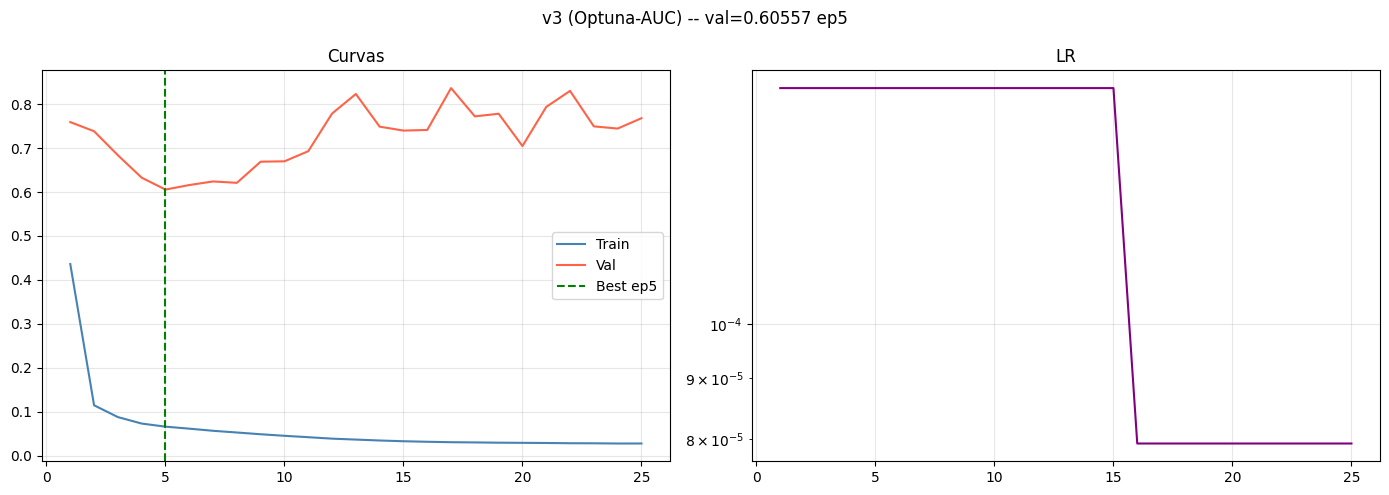

Gap val/train: 9.2x


In [10]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
er=range(1,len(train_hist)+1)
axes[0].plot(er,train_hist,label='Train',color='steelblue',lw=1.5)
axes[0].plot(er,val_hist,  label='Val',  color='tomato',   lw=1.5)
axes[0].axvline(best_ep,color='green',linestyle='--',lw=1.5,label=f'Best ep{best_ep}')
axes[0].set_title('Curvas'); axes[0].legend(); axes[0].grid(True,alpha=0.3)
axes[1].plot(er,lr_hist,color='purple',lw=1.5); axes[1].set_yscale('log')
axes[1].set_title('LR'); axes[1].grid(True,alpha=0.3)
plt.suptitle(f'v3 (Optuna-AUC) -- val={best_val:.5f} ep{best_ep}',fontsize=12)
plt.tight_layout()
plt.savefig(str(SAVE_DIR/'training_curve.png'),dpi=120,bbox_inches='tight')
plt.show()
gap=val_hist[best_ep-1]/max(train_hist[best_ep-1],1e-10)
print(f'Gap val/train: {gap:.1f}x')


## 7. Errores y umbrales

In [11]:
def recon_errors(model,Xc,Xd,alpha,bs=256):
    loader=DataLoader(TensorDataset(torch.tensor(Xc,dtype=torch.float32),torch.tensor(Xd,dtype=torch.float32)),batch_size=bs,shuffle=False)
    ec_l,ed_l=[],[]
    model.eval()
    with torch.no_grad():
        for xc,xd in loader:
            xc,xd=xc.to(device),xd.to(device); xc_hat,xd_hat=model(xc,xd)
            ec_l.extend(torch.mean((xc_hat-xc)**2,dim=(1,2)).cpu().numpy())
            ed_l.extend(torch.mean((xd_hat-xd)**2,dim=1).cpu().numpy())
    ec=np.array(ec_l);ed=np.array(ed_l); return ec,ed,alpha*ec+(1-alpha)*ed

err_tr_c,err_tr_d,err_tr=recon_errors(model,X_tr_c,X_tr_d,ALPHA)
err_va_c,err_va_d,err_va=recon_errors(model,X_va_c,X_va_d,ALPHA)
err_te_c,err_te_d,err_te=recon_errors(model,X_te_c,X_te_d,ALPHA)

print(f"{'Split':<8} {'Mean':>8} {'Std':>8} {'p90':>8} {'p95':>8} {'p99':>8}")
print('-'*50)
for name,err in [('Train',err_tr),('Val',err_va),('Test',err_te)]:
    print(f'{name:<8} {err.mean():>8.5f} {err.std():>8.5f} {np.percentile(err,90):>8.5f} {np.percentile(err,95):>8.5f} {np.percentile(err,99):>8.5f}')


Split        Mean      Std      p90      p95      p99
--------------------------------------------------
Train     0.06511  0.12446  0.12489  0.20749  0.83780
Val       0.61118  1.83254  0.53029  7.34626  8.12676
Test     23155670.00000 193489072.00000  0.22518  0.41102 1190525056.00000


In [12]:
PERCENTILES=[90,95,97.5,99,99.5]
tau_dict={f'p{str(p).replace(".","_")}':float(np.percentile(err_te,p)) for p in PERCENTILES}
print('Umbrales sobre test normal:')
for k,v in tau_dict.items():
    far=(err_te>v).mean()
    print(f'  {k:8s}: {v:.6f}  FAR={100*far:.2f}%')


Umbrales sobre test normal:
  p90     : 0.225181  FAR=10.07%
  p95     : 0.411023  FAR=5.03%
  p97_5   : 1.409180  FAR=2.57%
  p99     : 1190525056.000000  FAR=1.09%
  p99_5   : 1943351808.000000  FAR=0.59%


## 8. Guardar artefactos

In [13]:
torch.save(model.state_dict(), SAVE_DIR/'model_state.pt')
with open(SAVE_DIR/'tau_dict.json','w') as f: json.dump(tau_dict,f,indent=4)
with open(SAVE_DIR/'columns_config.json','w') as f:
    json.dump({'continuous_cols':continuous_cols,'discrete_cols':discrete_cols,'feature_cols':feature_cols},f,indent=4)
config={
    'version':'a12_final_v3_optuna_auc','dataset':'SWaT A12 Mar 2026',
    'split':'chronological_60_20_20','optuna_objective':'maximize_roc_auc',
    'best_auc_optuna':float(optuna_cfg['best_auc_optuna']),
    'warmup_seconds':WARMUP,'n_train':len(df_train),'n_val':len(df_val),'n_test':len(df_test),
    'window_size':WINDOW_SIZE,'stride':STRIDE,'alpha':float(ALPHA),
    'best_epoch':best_ep,'best_val_loss':float(best_val),
    'train_loss_at_best':float(train_hist[best_ep-1]),
    'n_windows_train':int(len(X_tr_c)),'n_windows_val':int(len(X_va_c)),'n_windows_test':int(len(X_te_c)),
    'cont_channels':int(X_tr_c.shape[1]),'disc_dim':int(X_tr_d.shape[1]),
    'continuous_cols':continuous_cols,'discrete_cols':discrete_cols,'feature_cols':feature_cols,
    'scenarios':['real_only','synthetic_only','real_plus_synthetic'],
    'model_params':{k:(float(v) if isinstance(v,float) else v) for k,v in bp.items()},
    'tau_dict':tau_dict,
    'error_stats':{'test_mean':float(err_te.mean()),'test_std':float(err_te.std()),
                   'test_p90':float(np.percentile(err_te,90)),'test_p95':float(np.percentile(err_te,95)),
                   'test_p99':float(np.percentile(err_te,99))}
}
with open(SAVE_DIR/'config.json','w') as f: json.dump(config,f,indent=4)
print('Artefactos guardados en:', SAVE_DIR.resolve())
for fp in sorted(SAVE_DIR.iterdir()): print(f'  {fp.name}')


Artefactos guardados en: D:\Documentos\Uniandes\12 Semestre\PROYECTO DE GRADO\repoPrincipal\ics-synthetic-data-augmentation\models\detectors\conv1d_hybrid_a12_v3
  columns_config.json
  config.json
  disc_max_dict.pkl
  model_state.pt
  scaler_cont.pkl
  tau_dict.json
  training_curve.png
